# Week 6 - Bivariate Analysis, part 2

# 1. Lesson: no lesson this week

# 2. Weekly graph question

Suppose you wanted to show the nitrate and phosphate level in a water sample.  What are the advantages and disadvantages of showing this as an area plot, as opposed to two separate line graphs?  How would you adjust the graphs shown to improve the presentation?

In [2]:
import numpy as np
import seaborn as sns
import pandas as pd

/tmp/ipykernel_41450/2149468501.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')


Text(0, 0.5, 'Nitrate level (% of eutrophic value)')

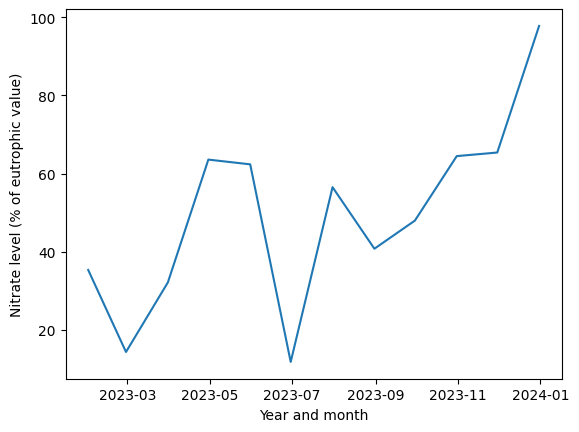

In [ ]:
numdates = 12
np.random.seed(0)
time_series = 100 * (np.random.normal(size = numdates) / 5 + np.arange(numdates) / 16)
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')
ax = sns.lineplot(x = datearray, y = time_series)
ax.set_xlabel("Year and month")
ax.set_ylabel("Nitrate level (% of eutrophic value)")

/tmp/ipykernel_41450/1726504607.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')


Text(0, 0.5, 'Phosphate level (% of eutrophic value)')

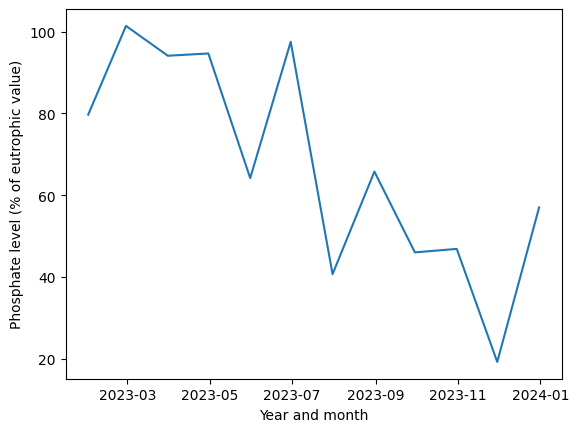

In [ ]:
np.random.seed(1)
time_series_2 =  100 * (1 - (np.random.normal(size = numdates) / 8 + np.arange(numdates) / 16))
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')
ax = sns.lineplot(x = datearray, y = time_series_2)
ax.set_xlabel("Year and month")
ax.set_ylabel("Phosphate level (% of eutrophic value)")

<Axes: >

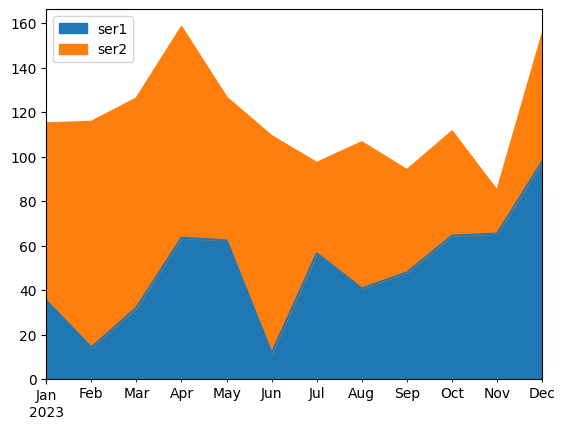

In [ ]:
df = pd.DataFrame({'ser1': time_series, 'ser2': time_series_2}, index = datearray)
df.plot.area()

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do:

- Find correlations between pairs of variables.

- Draw scatterplots, especially when the correlation is large.

- Draw pairplots.

- Draw line graphs and/or area graphs when there is date or time data together with numerical data.

### Conclusions:

- Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable?  If the data are not useable, find some new data!

- Do you see any outliers?  (Data points that are far from the rest of the data).

- Are any data items highly correlated with each other, suggesting that they are redundant?

- For the line plots, do you see a trend or pattern over time?  Does this suggest that the data are changing over time (drifting) in such a way as to invalidate comparisons?

- Can you think of any confounding variables?  (Third variables that could explain any correlations between other variables.  These third variables may or may not be reported in the dataset.)

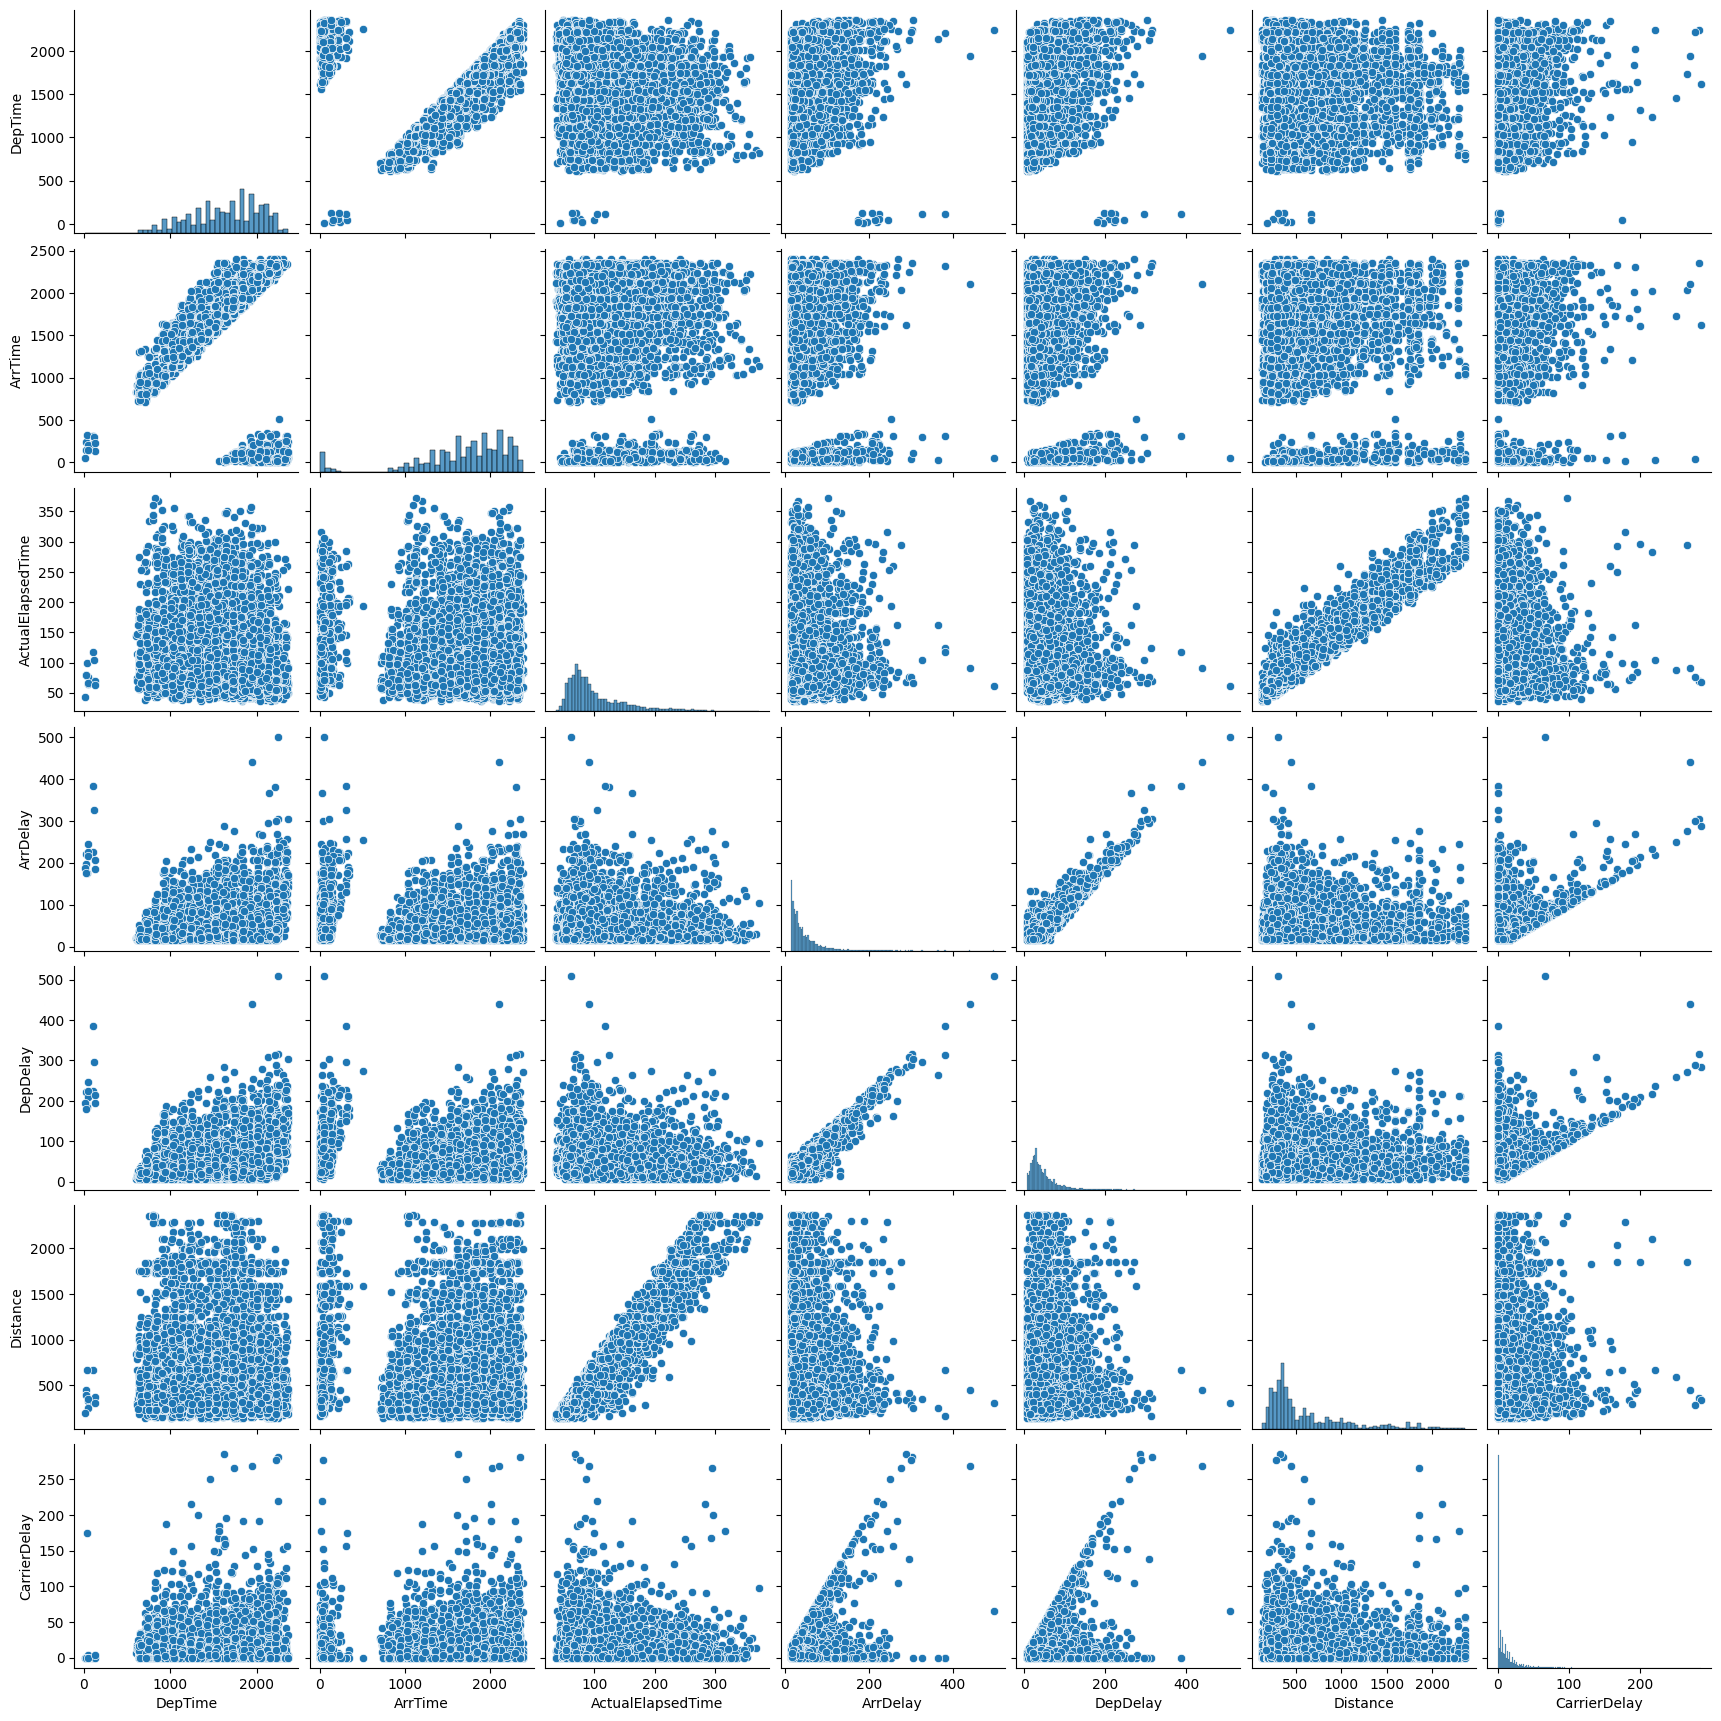

In [ ]:
#print all the correlation with graphs
from datetime import datetime, timedelta
df_flight = pd.read_csv("flight_data.csv", encoding="latin1")

#dropped columns that had very little correlation
columns_to_drop = ["UniqueCarrier", "Airline", "TailNum", "Org_Airport", "Dest_Airport", "CancellationCode", "SecurityDelay", "WeatherDelay","NASDelay", "CRSArrTime", "CRSElapsedTime", "Diverted", "DayOfWeek", "NASDelay", "LateAircraftDelay", "TailNum" , "Cancelled", "AirTime", "FlightNum", "TaxiIn", "TaxiOut"]
df_pairplot = df_flight.drop(columns_to_drop, axis=1)
sns.pairplot(df_pairplot)

In [ ]:
#had to drop the strings and data as the correlation data was not working
columns_to_drop = ["Date", "UniqueCarrier", "Airline", "TailNum", "Origin", "Org_Airport", "Dest", "Dest_Airport", "CancellationCode"]
df_calc = df_flight.drop(columns_to_drop, axis=1)
print("Correlations:",df_calc.corr())

Correlations:                    DayOfWeek   DepTime   ArrTime  CRSArrTime  FlightNum  \
DayOfWeek           1.000000  0.072095  0.054746    0.057460  -0.006679   
DepTime             0.072095  1.000000  0.417155    0.719840   0.036505   
ArrTime             0.054746  0.417155  1.000000    0.611297   0.000550   
CRSArrTime          0.057460  0.719840  0.611297    1.000000   0.004878   
FlightNum          -0.006679  0.036505  0.000550    0.004878   1.000000   
ActualElapsedTime   0.012706 -0.113782 -0.119189   -0.076232   0.028478   
CRSElapsedTime      0.018292 -0.079527 -0.115111   -0.056650   0.030642   
AirTime             0.010652 -0.095474 -0.115608   -0.064177   0.028012   
ArrDelay           -0.010804  0.185810 -0.067638    0.064796  -0.005336   
DepDelay           -0.001924  0.233643 -0.063557    0.092253  -0.001347   
Distance            0.018504 -0.068079 -0.135554   -0.061313   0.024231   
TaxiIn              0.051153  0.022616  0.048133    0.037480  -0.001927   
TaxiOut    

In [3]:
import matplotlib.pyplot as plt

Text(0, 0.5, 'DepDelay (min)')

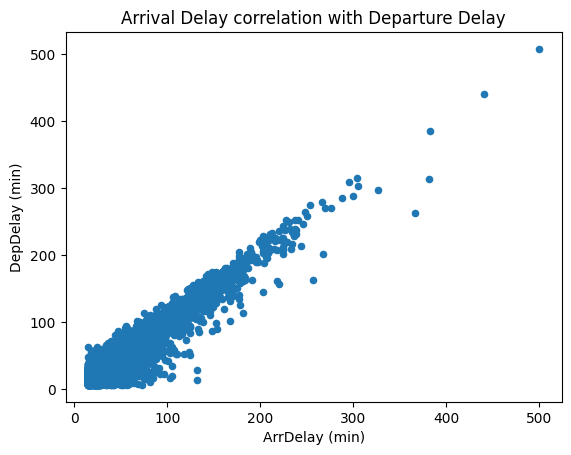

In [ ]:
#Besides obvious correlations with actual elapsed time with airtime, actual elapsted time and CRS elapsed time, or distance and air time.
#I will look into the following: arrival delay and departure delay (0.95 correlation), late aircraft delay and departure delay (0.75 correlation), and departure time and CRS arrival time (0.72 correlation).

df_flight.plot.scatter(x="ArrDelay", y="DepDelay")
plt.title("Arrival Delay correlation with Departure Delay")
plt.xlabel("ArrDelay (min)")
plt.ylabel("DepDelay (min)")

Text(0, 0.5, 'DepDelay (min)')

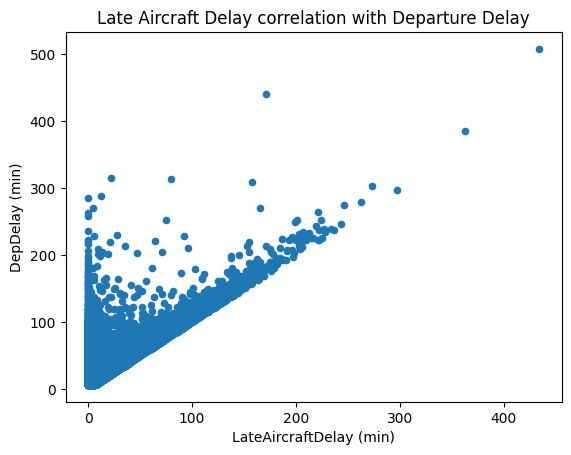

In [ ]:
df_flight.plot.scatter(x="LateAircraftDelay", y="DepDelay")
plt.title("Late Aircraft Delay correlation with Departure Delay")
plt.xlabel("LateAircraftDelay (min)")
plt.ylabel("DepDelay (min)")

Text(0, 0.5, 'DepDelay (min)')

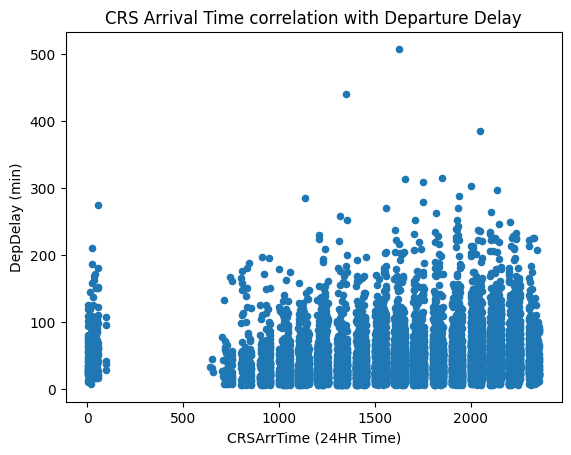

In [ ]:
df_flight.plot.scatter(x="CRSArrTime", y="DepDelay")
plt.title("CRS Arrival Time correlation with Departure Delay")
plt.xlabel("CRSArrTime (24HR Time)")
plt.ylabel("DepDelay (min)")

Text(0, 0.5, 'Total Delay (Min)')

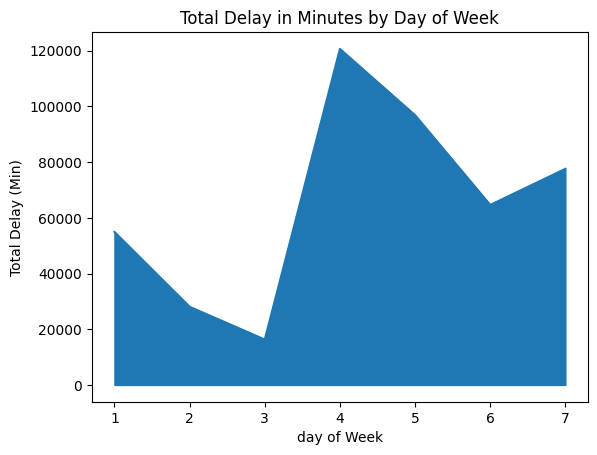

In [ ]:
#Create an area plot of delays with the day of week
delay_cols=["CarrierDelay","WeatherDelay","NASDelay","SecurityDelay","LateAircraftDelay"]

df_flight_fixed["TotalDelayTime"]=df_flight_fixed[delay_cols].sum(axis=1)

by_day=df_flight_fixed.groupby("DayOfWeek")["TotalDelayTime"].sum().sort_index()
by_day.plot(kind="area")
plt.title("Total Delay in Minutes by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Total Delay (Min)")

Text(0, 0.5, 'Total Count of flights with Arrival Delay')

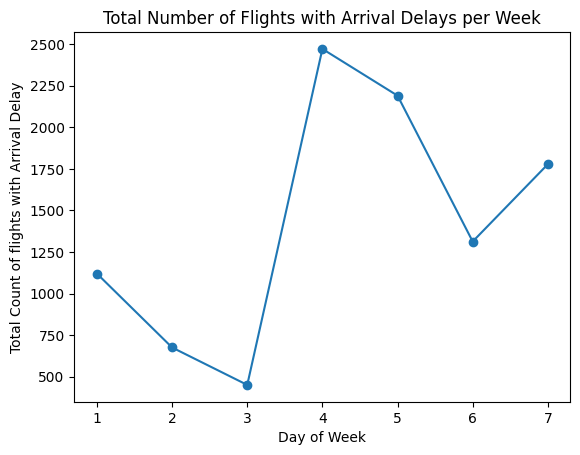

In [ ]:
#Total delayed flights per DayOfWeek
delayed_count = df_flight.assign(IsDelayed=df_flight["ArrDelay"]>0).groupby("DayOfWeek")["IsDelayed"].sum().sort_index()

delayed_count.plot(kind="line", marker="o")
plt.title("Total Number of Flights with Arrival Delays per Week")
plt.xlabel("Day of Week")
plt.ylabel("Total Count of flights with Arrival Delay")

### Conclusions:

- Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable?  If the data are not useable, find some new data!
Overall, the data look realistic and usable for analyzing flight delays. The distributions match expectations most flights have little to no delay. The strongest relationships also make sense operationally—DepDelay and ArrDelay are highly correlated, and LateAircraftDelay is strongly related to overall delays. The dataset is large and includes many categorical fields (airports/flight identifiers), so analysis is most readable when focusing on top airports and key numeric variables.

- Do you see any outliers?  (Data points that are far from the rest of the data).
Yes. Many variables—especially ArrDelay, DepDelay, TaxiIn/TaxiOut, and the delay cause columns contain outliers (very large values that occur rarely). These outliers are expected in airline operations and likely represent disruptions such as congestion, and irregular events. These extreme values are important because they explain why averages can be pulled upward and why medians/percentiles are often more informative.

- Are any data items highly correlated with each other, suggesting that they are redundant? 
Yes. Several flight duration variables are highly correlated and partially redundant: ActualElapsedTime, CRSElapsedTime, AirTime, and Distance are all strongly related because longer routes generally take more time. Also, ArrDelay and DepDelay measure closely related concepts (departure delay often propagates into arrival delay). Because of this redundancy, it would be reasonable to keep one representative duration variable (i.e., Distance or AirTime) rather than all of them for modeling or pairplots.

- For the line plots, do you see a trend or pattern over time?  
The line/area plots suggest that total delay minutes vary across time (by day of week and across the dataset’s date range), but there is no evidence of extreme drift that would invalidate comparisons. The main effect appears to be that certain time periods or days have more total delay, which can be influenced by how many flights occurred during that period. A helpful follow up would be to compare average delay per flight (not just total delay minutes) to separate more flights from worst performance. 

- Can you think of any confounding variables?  (Third variables that could explain any correlations between other variables.  These third variables may or may not be reported in the dataset.)
A key confounding varaible is flight volume. Total delay minutes can rise simply because there are more flights (more opportunities for delays), not necessarily because operations are worse. Other likely confounders include airport congestion, time of day, season/weather, route distance, and busy seasons. These factors could influence both delay likelihood and delay length, even if they are not explicitly modeled.

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 86-98 of the Storytelling With Data book as best you can.  (The second half of chapter three).  You do not have to get the exact data values right, just the overall look and feel.

[Text(0, 0, 'January'),
 Text(1, 0, 'February'),
 Text(2, 0, 'March'),
 Text(3, 0, 'April'),
 Text(4, 0, 'June'),
 Text(5, 0, 'July'),
 Text(6, 0, 'August'),
 Text(7, 0, 'September'),
 Text(8, 0, 'October'),
 Text(9, 0, 'November'),
 Text(10, 0, 'December')]

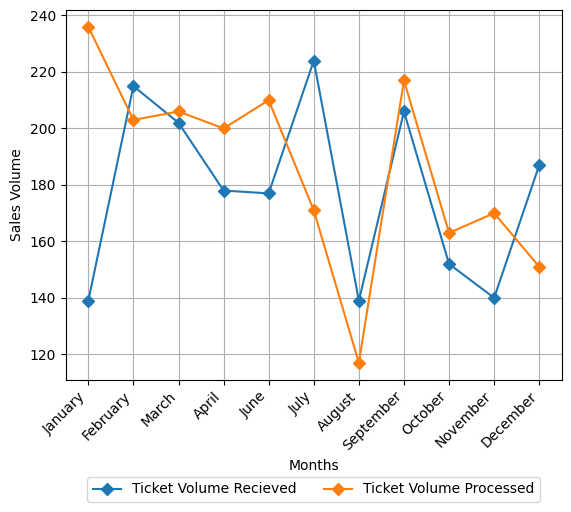

In [15]:
months = ["January", "February", "March", "April", "June", "July", "August", "September", "October", "November", "December"]

xs= np.arange(len(months))
#equation will be a negative parabola y=-ax^2+bx + c

rng=np.random.default_rng(42)
y1= rng.integers(130, 240, size=len(months))
y2=rng.integers(100, 240, size=len(months)) 

df = pd.DataFrame({'Ticket Volume Recieved': y1, 'Ticket Volume Processed': y2}, index = months)

ax=df.plot(kind="line", marker="D", grid=True) 
ax.legend(loc="lower center", bbox_to_anchor=(0.5,-0.35), ncol=2)
plt.xlabel("Months")
plt.ylabel("Sales Volume")

ax.set_xticks(np.arange(len(df.index)))
ax.set_xticklabels(df.index, rotation=45, ha="right")